# Лабораторные работы № 1–2
## Подготовка и анализ данных о пассажиропотоке метро

**Фамилия, имя:** _Пузанков Максим___________________  

В первой работе вы загрузите CSV и подготовите таблицу для анализа. Во второй — сравните показатели за один квартал, построите графики и сохраните отчёт.

Дополняйте заготовки под заданиями. Многоточие в коде обозначает место для вашего решения: замените его нужным выражением. Комментарии подсказывают, что осталось сделать. Ответы и выводы записывайте в текстовые ячейки. Если проверка не выявила ошибок, так и укажите.

## Перед началом

Рядом с блокнотом должны лежать файл `requirements.txt` и папка `data` с файлом `data-62743-08-09-2026.csv`. Результаты сохраняйте в отдельную папку `student_outputs`. Исходный CSV не редактируйте.


### Имена переменных

Используйте предложенные имена: они повторяются в следующих заданиях.

| Имя | Что хранит |
|---|---|
| `DATA_PATH`, `OUTPUT_DIR` | Путь к исходному файлу и папке результатов |
| `raw` | Таблица сразу после импорта |
| `df` | Рабочая таблица после подготовки |
| `KEY` | Поля, по которым проверяется уникальность записи |
| `coverage` | Число записей, станций и линий по кварталам |
| `export_df` | Поля подготовленной таблицы для экспорта |
| `selected` | Записи выбранного квартала |
| `summary` | Основные показатели выбранного квартала |
| `top`, `by_line` | Рейтинг и сводка по линиям |
| `quarterly` | Сумма входов и число записей по кварталам |
| `profile_data`, `profile` | Данные для профилирования и объект отчёта |
| `reloaded` | Таблица, повторно прочитанная из сохранённого CSV |
| `practice` | Отдельная учебная копия для дополнительных заданий |

Импорты, пути и параметры уже заданы. Расчёты, очистку и графики допишите самостоятельно. Ячейки с многоточиями пока не готовы к выполнению: сначала заполните пропуски и предусмотренные комментариями действия, затем запускайте ячейки по порядку.

### Подготовка среды

Проверьте, что выбрано нужное ядро Python. Если библиотеки ещё не установлены, установите зависимости из `requirements.txt` в это ядро и перезапустите его. Если среда уже готова, оставьте ячейку пустой и переходите дальше.

In [83]:
# Выполните только при необходимости, затем перезапустите ядро.
# %pip install -r requirements.txt

## Лабораторная работа № 1. Загрузка и проверка данных

Начните с вопроса: какие станции имеют больше всего входов пассажиров за выбранный квартал? По ходу работы уточните, как в файле обозначена станция и какие записи можно сравнивать между собой.

### 1.1. Библиотеки

Подключите pandas для работы с таблицами, pyplot из matplotlib для графиков и Path из pathlib для работы с путями. Выведите версию pandas. Остальные библиотеки подключайте по мере необходимости.

In [84]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', 15)
plt.rcParams['font.family'] = 'DejaVu Sans'

print('pandas:', pd.__version__)

pandas: 2.3.3


### 1.2. Путь к файлу

Задайте путь к исходному CSV и папке `student_outputs`. Проверьте, что файл существует, и создайте папку для результатов, если её ещё нет. Выведите имя и размер исходного файла.

In [85]:
BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / 'data' / 'data-62743-08-09-2026.csv'
OUTPUT_DIR = BASE_DIR / 'student_outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

# Проверьте наличие файла и выведите его имя и размер.
if DATA_PATH.exists():
    file_name = DATA_PATH.name
    
    # Получаем размер файла в байтах
    file_size = DATA_PATH.stat().st_size
    
    print(f"Имя файла: {file_name}")
    print(f"Размер файла: {file_size} байт")
else:
    print(f"Файл по адресу {DATA_PATH} не найден.")


Имя файла: data-62743-08-09-2026.csv
Размер файла: 868672 байт


### 1.3. Первые строки файла

Прочитайте первые три строки CSV как обычный текст и выведите их на экран. Определите разделитель и убедитесь, что русские буквы отображаются правильно. Пока ничего не удаляйте.

In [86]:
# Прочитайте первые три строки файла DATA_PATH как текст.
with open(DATA_PATH, 'r', encoding='utf-8') as file:
    first_lines = [file.readline().strip() for _ in range(3)]

# Выведите строки и определите разделитель.
for i, line in enumerate(first_lines, start=1):
    print(f"Строка {i}: {line}")

Строка 1: "Metro station name";"Line name";"Year";"Quarter";"Incoming passengers";"Outgoing passengers";"global_id";
Строка 2: "Станция метрополитена";"Линия";"Год";"Квартал";"Входы пассажиров";"Выходы пассажиров";"global_id";
Строка 3: "Митино";"Арбатско-Покровская линия";"2021";"I квартал";"1913498";"1829031";"1138975996";


### 1.4. Импорт таблицы

Загрузите файл в pandas с подходящими разделителем и кодировкой. На этом шаге прочитайте все поля как строки, чтобы сохранить исходные значения.

Назовите таблицу `raw`. Покажите первые пять записей, размер таблицы и названия столбцов. Сопоставьте результат с текстом файла из предыдущего задания.

In [87]:
# Загрузите CSV. Сначала прочитайте все поля как строки.
raw = pd.read_csv(DATA_PATH, dtype=str, sep=';', encoding='utf-8')

# Покажите первые записи, размер и названия столбцов.
print(f"Размер таблицы: {raw.shape}")
print(f"\nНазвания столбцов: {raw.columns.tolist()}")
print(f"\nПервые пять записей:\n{raw.head(5)}")

Размер таблицы: (6449, 8)

Названия столбцов: ['Metro station name', 'Line name', 'Year', 'Quarter', 'Incoming passengers', 'Outgoing passengers', 'global_id', 'Unnamed: 7']

Первые пять записей:
      Metro station name                  Line name  Year    Quarter  \
0  Станция метрополитена                      Линия   Год    Квартал   
1                 Митино  Арбатско-Покровская линия  2021  I квартал   
2          Волоколамская  Арбатско-Покровская линия  2021  I квартал   
3               Строгино  Арбатско-Покровская линия  2021  I квартал   
4             Крылатское  Арбатско-Покровская линия  2021  I квартал   

  Incoming passengers Outgoing passengers   global_id Unnamed: 7  
0    Входы пассажиров   Выходы пассажиров   global_id        NaN  
1             1913498             1829031  1138975996        NaN  
2             1236714             1222309  1138975997        NaN  
3             1938816             1903731  1138975999        NaN  
4             1849616             18

### 1.5. Первый осмотр

Выведите сведения о типах столбцов и количестве заполненных значений. Для каждого столбца посчитайте пропуски.

Проверьте, все ли строки содержат наблюдения и все ли столбцы несут полезную информацию. Запишите, что требует исправления.

In [88]:
# Выведите сведения о таблице raw.
raw.info()
# Посчитайте пропуски по столбцам.
missing_raw = raw.isnull().sum()

# Покажите результат проверки.
print("\nПропуски по столбцам:")
print(missing_raw)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6449 entries, 0 to 6448
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Metro station name   6449 non-null   object
 1   Line name            6449 non-null   object
 2   Year                 6449 non-null   object
 3   Quarter              6449 non-null   object
 4   Incoming passengers  6449 non-null   object
 5   Outgoing passengers  6449 non-null   object
 6   global_id            6449 non-null   object
 7   Unnamed: 7           0 non-null      object
dtypes: object(8)
memory usage: 403.2+ KB

Пропуски по столбцам:
Metro station name        0
Line name                 0
Year                      0
Quarter                   0
Incoming passengers       0
Outgoing passengers       0
global_id                 0
Unnamed: 7             6449
dtype: int64


Восьмой столбец "Unnamed: 7" полностью пустой, появился он из-за лишней запятой в конце каждой строки.
Первая строка таблицы содержит повторяющиеся заголовки на русском языке.

Почему на этом этапе нельзя удалять все строки, в которых встретился хотя бы один пропуск?
Ответ: Потому что столбец "Unnamed: 7" состоит только из пропусков во всех 6449 строках. В случае удаления строки с пропуском удалятся все данные из таблицы.

### 1.6. Служебные строки и столбцы

Создайте рабочую таблицу `df` на основе `raw`. Если нашли служебную строку, исключите её по содержимому. Полностью пустой технический столбец удалите после проверки. Исходную таблицу `raw` сохраните.

Используйте русские названия полей из файла: «Станция метрополитена», «Линия», «Год», «Квартал», «Входы пассажиров», «Выходы пассажиров». Название `global_id` оставьте без изменений.

Выведите размер таблицы до и после исправления. Начните журнал изменений в текстовой таблице ниже.

In [89]:
column_names = {
    'Metro station name': 'Станция метрополитена',
    'Line name': 'Линия',
    'Year': 'Год',
    'Quarter': 'Квартал',
    'Incoming passengers': 'Входы пассажиров',
    'Outgoing passengers': 'Выходы пассажиров',
    'global_id': 'global_id',
}

# Найдите служебные строки и пустые технические столбцы.
service_rows = raw['Metro station name'] == "Станция метрополитена"
empty_columns = [col for col in raw.columns if raw[col].isnull().all()]

# Получите рабочую таблицу, исключив служебные элементы.
df = raw[~service_rows].drop(columns=empty_columns).copy()

# Используйте column_names для переименования полей.
df = df.rename(columns=column_names)

# Сравните размер raw и df.
print(f"\nРазмер исходной таблицы raw: {raw.shape}")
print(f"Размер рабочей таблицы df: {df.shape}")
display(df.head(3))


Размер исходной таблицы raw: (6449, 8)
Размер рабочей таблицы df: (6448, 7)


,Станция метрополитена,Линия,Год,Квартал,Входы пассажиров,Выходы пассажиров,global_id
1,Митино,Арбатско-Покровская линия,2021,I квартал,1913498,1829031,1138975996
2,Волоколамская,Арбатско-Покровская линия,2021,I квартал,1236714,1222309,1138975997
3,Строгино,Арбатско-Покровская линия,2021,I квартал,1938816,1903731,1138975999


### Текстовый журнал изменений

| Действие | Причина / Описание | Было (строк × столбцов) | Стало (строк × столбцов) |
| :--- | :--- | :---: | :---: |
| Удаление столбца `Unnamed: 7` | Пустой столбец из-за лишней `;` в конце строк | 6449 × 8 | 6449 × 7 |
| Удаление строки 0 | Повторный заголовок («Станция метрополитена»...) | 6449 × 7 | 6448 × 7 |
| Переименование столбцов | Приведение названий колонок к кириллице | 6448 × 7 | 6448 × 7 |


### 1.7. Текстовые значения

Уберите пробелы по краям текстовых значений. Строки, в которых после этого ничего не осталось, обозначьте как пропуски. Посчитайте, сколько ячеек изменилось.

Не заменяйте названия станций и линий произвольно: сначала убедитесь, что разные варианты действительно обозначают один объект.

In [90]:
text_columns = df.select_dtypes(include=['object', 'string']).columns
before_text = df[text_columns].copy()

# В df уберите пробелы по краям и обозначьте пустые строки как пропуски.
for col in text_columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace('', pd.NA)
# Сравните результат с before_text.
text_changes = (before_text != df[text_columns]).sum().sum()
print(f"Количество измененных ячеек после очистки текста: {text_changes}")

Количество измененных ячеек после очистки текста: 0


### 1.8. Числовые поля

Преобразуйте год, число входов и число выходов в числа. Отдельно проверьте значения, которые не удалось преобразовать, и покажите проблемные записи, если они есть.

Проверьте, что числа целые. Идентификатор `global_id` оставьте строковым. Выведите типы полей после преобразования.

In [91]:
numeric_columns = ['Год', 'Входы пассажиров', 'Выходы пассажиров']

# Преобразуйте эти поля в числа и проверьте ошибки преобразования.
for col in numeric_columns:
    # Переводим текст в числа, а всё, что не перевелось, временно заменяем на NaN 
    converted = pd.to_numeric(df[col], errors='coerce')
    failed_rows = df[col][converted.isna() & df[col].notna()]#выбирает строки, где преобразование не удалось, но исходное значение не было пустым.

    if not failed_rows.empty:
        print(f"\nОшибка преобразования в столбце '{col}':")
        print(failed_rows)

# Проверьте целочисленность значений. global_id оставьте строковым.
    is_integer = (converted % 1 == 0).all()
    print(f"Столбец '{col}' содержит только целые числа: {is_integer}")

    df[col] = converted.astype('Int64')
    df['global_id'] = df['global_id'].astype(str)# Оставляем id строковвым

# Покажите итоговые типы столбцов df.
print("\nИтоговые типы столбцов df:")
print(df.dtypes)

Столбец 'Год' содержит только целые числа: True
Столбец 'Входы пассажиров' содержит только целые числа: True
Столбец 'Выходы пассажиров' содержит только целые числа: True

Итоговые типы столбцов df:
Станция метрополитена    object
Линия                    object
Год                       Int64
Квартал                  object
Входы пассажиров          Int64
Выходы пассажиров         Int64
global_id                object
dtype: object


### 1.9. Пропуски и повторные записи

Составьте таблицу: для каждого поля укажите тип, количество и долю пропусков, число уникальных значений.

Проверьте отдельно полные повторы строк, повторы `global_id` и повторы сочетания станции, линии, года и квартала. Если повторы найдены, выведите все записи соответствующих групп, чтобы их можно было сравнить.

In [92]:
KEY = ['Станция метрополитена', 'Линия', 'Год', 'Квартал']

# Составьте таблицу качества по каждому полю.
quality = pd.DataFrame({
    'Тип данных': df.dtypes,
    'Количество пропусков': df.isnull().sum(),
    'Доля пропусков (%)': (df.isnull().mean() * 100).round(2),
    'Уникальных значений': df.nunique()
})

# Найдите полные повторы, повторные идентификаторы и ключи.
full_duplicates = df[df.duplicated(keep=False)]
id_duplicates = df[df.duplicated(subset=['global_id'], keep=False)]
key_duplicates = df[df.duplicated(subset=KEY, keep=False)]

# Покажите таблицу качества и найденные повторные записи.
print("Таблица качества данных по полям:")
display(quality)

print(f"Количество полных повторов строк: {len(full_duplicates)}")
print(f"Количество повторов по global_id: {len(id_duplicates)}")
print(f"Количество повторов по ключу {KEY}: {len(key_duplicates)}")

if not full_duplicates.empty:
    print("\nПолные дубликаты строк:")
    display(full_duplicates)

if not id_duplicates.empty:
    print("\nДубликаты по global_id:")
    display(id_duplicates.sort_values('global_id'))

if not key_duplicates.empty:
    print("\nДубликаты по сочетанию Станции, Линии, Года и Квартала:")
    display(key_duplicates.sort_values(KEY))

Таблица качества данных по полям:


,Тип данных,Количество пропусков,Доля пропусков (%),Уникальных значений
Станция метрополитена,object,0,0.0,263
Линия,object,0,0.0,18
Год,Int64,0,0.0,6
Квартал,object,0,0.0,4
Входы пассажиров,Int64,0,0.0,6250
Выходы пассажиров,Int64,0,0.0,6246
global_id,object,0,0.0,6448


Количество полных повторов строк: 0
Количество повторов по global_id: 0
Количество повторов по ключу ['Станция метрополитена', 'Линия', 'Год', 'Квартал']: 0


Можно ли считать одно название станции уникальным ключом строки? Объясните на примере из таблицы.

Ответ: Нет нельзя, поскольку название станции может встречаться на разных ветках. Например, станция Арбатская есть и на Арбатско-покровской ветке, и на Филевской линии. Также можно заметить, что данные собираются по кварталам, следовательно одно и то же название станции повторяется. 

### 1.10. Очистка и проверка значений

Удалите полные повторные строки, если они есть, и посчитайте число удалённых записей. Если один ключ соответствует разным данным, покажите конфликт и обсудите его с преподавателем; не выбирайте одну запись случайно.

Проверьте счётчики на отрицательные значения. Посчитайте записи с нулевыми входами, с нулевыми выходами и с обоими нулевыми показателями. Выведите несколько таких записей, если они есть. Нули пока сохраните.

In [93]:
before_dedup = len(df)

# Удалите из df только полные повторы, если они есть.
df = df.drop_duplicates().copy()

removed_rows = before_dedup - len(df)
negative_rows = df[(df['Входы пассажиров'] < 0) | (df['Выходы пассажиров'] < 0)]
zero_incoming = df[df['Входы пассажиров'] == 0]
zero_outgoing = df[df['Выходы пассажиров'] == 0]
zero_both = df[(df['Входы пассажиров'] == 0) & (df['Выходы пассажиров'] == 0)]

# Покажите число удалённых строк и результаты проверок счётчиков.
print(f"Удалено полных дубликатов: {removed_rows}")
print(f"Записей с отрицательными значениями: {len(negative_rows)}")
print(f"Записей с нулевыми входами: {len(zero_incoming)}")
print(f"Записей с нулевыми выходами: {len(zero_outgoing)}")
print(f"Записей с обоими нулевыми показателями: {len(zero_both)}")
# Нулевые записи сохраните в df.
if not zero_both.empty:
    print("\nПримеры записей с нулевыми показателями:")
    display(zero_both.head(5))

Удалено полных дубликатов: 0
Записей с отрицательными значениями: 0
Записей с нулевыми входами: 193
Записей с нулевыми выходами: 193
Записей с обоими нулевыми показателями: 193

Примеры записей с нулевыми показателями:


,Станция метрополитена,Линия,Год,Квартал,Входы пассажиров,Выходы пассажиров,global_id
23,Новослободская,Кольцевая линия,2021,I квартал,0,0,1138976067
29,Рижская,Калужско-Рижская линия,2021,I квартал,0,0,1138976089
134,Мнёвники,Большая кольцевая линия,2021,I квартал,0,0,1138976397
151,Народное Ополчение,Большая кольцевая линия,2021,I квартал,0,0,1138976442
310,Новослободская,Кольцевая линия,2021,II квартал,0,0,1139049667


Каких сведений не хватает, чтобы решить, являются ли нулевые значения ошибками?

Ответ: Не хватает сведений таких как:
1. информации о плановом ремонте или закрытии станции;
2. учета пассажиропотока;
3. учета новых станций, на которых еще не запустили движение поездов

### 1.11. Кварталы и состав данных

Добавьте номер квартала от 1 до 4 по текстовому обозначению. Проверьте, что все обозначения удалось распознать. Создайте поле периода, по которому кварталы можно расположить в хронологическом порядке.

Определите первый и последний кварталы в файле. Посчитайте разные названия станций и линий за весь период. Для каждого квартала составьте сводку: число записей, число разных названий станций и число линий.

In [94]:
# Заполните соответствие текстовых обозначений номерам кварталов.
quarter_numbers = {
    'I квартал': 1,
    'II квартал': 2,
    'III квартал': 3,
    'IV квартал': 4
}

# Добавьте в df столбцы «Номер квартала» и «Период».
df['Номер квартала'] = df['Квартал'].map(quarter_numbers)

# Проверьте, что все обозначения кварталов распознаны.
unmapped_count = df['Номер квартала'].isnull().sum()
print(f"Количество нераспознанных кварталов: {unmapped_count}")

df['Период'] = df['Год'].astype(str) + '-кв' + df['Номер квартала'].astype(str)# Создаем поле периода для хронологической сортировки (например, '2021-Q1')

# Определяем первый и последний кварталы, а также общее число станций и линий
first_period = df['Период'].min()
last_period = df['Период'].max()
total_stations = df['Станция метрополитена'].nunique()
total_lines = df['Линия'].nunique()

print(f"Первый квартал в файле: {first_period}")
print(f"Последний квартал в файле: {last_period}")
print(f"Всего разных станций за весь период: {total_stations}")
print(f"Всего разных линий за весь период: {total_lines}")


# Составьте сводку по кварталам: записи, названия станций, линии.
coverage = df.groupby('Период').agg(
    Число_записей=('global_id', 'count'),
    Число_станций=('Станция метрополитена', 'nunique'),
    Число_линий=('Линия', 'nunique')
)

# Покажите границы периода, число станций и линий, сводку coverage.
print("\nСводка coverage по кварталам:")
display(coverage)

Количество нераспознанных кварталов: 0
Первый квартал в файле: 2021-кв1
Последний квартал в файле: 2026-кв2
Всего разных станций за весь период: 263
Всего разных линий за весь период: 18

Сводка coverage по кварталам:


,Число_записей,Число_станций,Число_линий
Период,,,
2021-кв1,266,237,16
2021-кв2,267,237,16
2021-кв3,269,237,17
2021-кв4,285,248,16
2022-кв1,285,248,16
2022-кв2,284,248,16
2022-кв3,285,248,16
2022-кв4,285,248,16
2023-кв1,294,251,16


Одинаков ли состав данных по кварталам? Какие ограничения это создаёт при сравнении показателей?

Ответ: Нет, состав данных не одинаков. Можно заметить, что в первом квартале 2021-кв1 присутствует 266 записей и 237 станций, и со временем показатели растут: число записей до 307, а число станций до 262.

Основные органичения не одинакового состава данных:
Нет возможности сравнить суммарное число входов и выходов (между любыми кварталами и годами), так как прирост суммарного показателя пассажиропотока может быть связан не с его ростом, а с добавлением новых станций и линий.
Для корректного анализа изменений, необходимо использовать величину среднего пассажиропотока на одну станцию.

### 1.12. Сохранение таблицы

Сохраните подготовленные данные в `student_outputs/metro_clean.csv`: включите семь исходных полей с русскими названиями и номер квартала. Служебный индекс pandas в файл не записывайте. Выберите кодировку, при которой сохраняется кириллица.

Закончите журнал исправлений. Укажите, сколько строк и столбцов осталось в таблице.

In [95]:
export_columns = list(column_names.values()) + ['Номер квартала']
export_df = df[export_columns].copy()
clean_csv_path = OUTPUT_DIR / 'metro_clean.csv'

# Сохраните export_df в clean_csv_path без служебного индекса.
export_df.to_csv(clean_csv_path, sep=';', index=False, encoding='utf-8-sig')
# Выведите размер сохранённой таблицы.
print(f"Размер сохранённой таблицы (строк, столбцов): {export_df.shape}")

Размер сохранённой таблицы (строк, столбцов): (6448, 8)


**Вывод по первой работе.** Кратко опишите особенности файла, выполненные проверки и внесённые исправления. Что ещё нужно узнать о данных перед анализом?

Файл содержит квартальную статистику пассажиропотока по станциям Московского метрополитена за период с 2021-кв1 по 2026-кв2.

- Первоначально файл содержал 6449 строк, включая 1 дублирующую строку заголовка и 8 столбцов, один из которых был полностью пустым.
- Внесенные изменения:
1. Удалена служебная строка дублирующихся заголовков.
2. Удален один пустой столбец (Unnamed: 7).
3. Оставшиеся семь столбцов были переименованы на русский язык.
4. Удалены ненужные пробельные символы по краям текстовых полей.
5. Столбцы Год, Входы пассажиров и Выходы пассажиров приведены к целочисленному типу данных (Int64).
6. Выполнена проверка пропусков, а также подтверждено отсутствие полных дубликатов строк и дубликатов по global_id.
7. Выявлены 193 записи с нулевыми показателями пассажиропотока.
8. Добавлен дополнительный столбец Номер квартала.

Итоговый размер сохраненной таблицы составил 6448 строк и 8 столбцов.

Что ещё нужно узнать о данных перед анализом:
- Причины нулевых показателей пассажиропотока (информация о временных закрытиях, ремонтах станций или сроках ввода новых станций в эксплуатацию).
- величину среднего пассажиропотока на одну станцию.
- Если пассажиропоток считается только по платным транзакциям, то данные будут неполными. Необходимо отдельно учесть проходы льготных категорий граждан.


## Лабораторная работа № 2. Анализ, графики и отчёт

Продолжайте работу с подготовленной таблицей. Если ядро перезапущено, сначала выполните свои ячейки первой работы.

Для основного сравнения возьмите II квартал 2026 года. В конце выберите другой квартал, повторите расчёты и отметьте, что изменилось.

### 2.1. Выбор периода

Задайте год, номер квартала и число записей для рейтинга отдельными параметрами. Для начала возьмите десять записей.

Отберите нужный квартал в отдельную таблицу. Проверьте, что она не пуста, выведите число записей и первые строки. Все рейтинги и распределения ниже стройте по этому срезу, если в задании не сказано иное.

In [96]:
ANALYSIS_YEAR = 2026
ANALYSIS_QUARTER = 2
TOP_N = 10

# Отберите строки df по году и номеру квартала.
selected = df[(df['Год'] == ANALYSIS_YEAR) & (df['Номер квартала'] == ANALYSIS_QUARTER)].copy()
period_title = f'{ANALYSIS_YEAR}, квартал {ANALYSIS_QUARTER}'

# Проверьте, что selected не пуста. Покажите размер и первые строки.
if not selected.empty:
    print(f"Данные успешно отобраны за период: {period_title}")
    print(f"Размер полученной таблицы (строк, столбцов): {selected.shape}")
    display(selected.head())
else:
    print(f"Ошибка: данные за {period_title} не найдены в датасете!")

Данные успешно отобраны за период: 2026, квартал 2
Размер полученной таблицы (строк, столбцов): (305, 9)


,Станция метрополитена,Линия,Год,Квартал,Входы пассажиров,Выходы пассажиров,global_id,Номер квартала,Период
6144,Бауманская,Арбатско-Покровская линия,2026,II квартал,4524678,4669398,5102430006,2,2026-кв2
6145,Измайловская,Арбатско-Покровская линия,2026,II квартал,1688364,1710946,5102430007,2,2026-кв2
6146,Семёновская,Арбатско-Покровская линия,2026,II квартал,2572369,2629605,5102430008,2,2026-кв2
6147,Митино,Арбатско-Покровская линия,2026,II квартал,1858660,1794968,5102430009,2,2026-кв2
6148,Партизанская,Арбатско-Покровская линия,2026,II квартал,1786826,1717427,5102430010,2,2026-кв2


### 2.2. Основные показатели

Выведите описательную статистику входов и выходов. Отдельно посчитайте число записей, сумму входов, среднее и медиану входов на запись, а также число записей с нулевыми входами.

Нулевые значения оставьте в расчёте. Подпишите период и единицы измерения.

In [97]:
# Получите описательную статистику двух счётчиков в selected.
statistics = selected[['Входы пассажиров', 'Выходы пассажиров']].describe()

# Рассчитайте показатели выбранного квартала.
summary = {
    'Записей': len(selected),
    'Сумма входов по записям': selected['Входы пассажиров'].sum(),
    'Среднее входов на запись': round(selected['Входы пассажиров'].mean(), 2),
    'Медиана входов на запись': selected['Входы пассажиров'].median(),
    'Записей с нулевыми входами': (selected['Входы пассажиров'] == 0).sum(),
}

# Покажите statistics и summary с указанием периода.
print(f"Описательная статистика за {period_title}:")
display(statistics)

print(f"\nСводные показатели за {period_title}:")
for key, value in summary.items():
    print(f"{key}: {value}")

Описательная статистика за 2026, квартал 2:


,Входы пассажиров,Выходы пассажиров
count,305.0,305.0
mean,2007840.75082,2002206.262295
std,1363924.344758,1339002.532905
min,0.0,0.0
25%,943052.0,922537.0
50%,1778826.0,1790509.0
75%,2686166.0,2666514.0
max,8390173.0,7220237.0



Сводные показатели за 2026, квартал 2:
Записей: 305
Сумма входов по записям: 612391429
Среднее входов на запись: 2007840.75
Медиана входов на запись: 1778826.0
Записей с нулевыми входами: 10


Сравните среднее и медиану. Что они показывают в этой таблице? Можно ли назвать сумму входов числом уникальных пассажиров?
Среднее число входов значительно выше медианы. Это связано с тем, что большинство станций имеют средний пассажиропоток, тогда как пересадочные узлы смещают среднее значение вверх.

Медиана показывает значение пассажиропотока центральной станции в упорядоченном ряду. Одна половина записей в таблице имеет показатель ниже этого значения, а вторая половина - выше.
Нет, сумму входов нельзя назвать числом уникальных пассажиров. Сумма входов - это общее количество поездок за квартал, которое один и тот же человек может совершать каждый день.

### 2.3. Рейтинг

Отберите десять записей с наибольшим числом входов. Покажите станцию, линию, входы и выходы. Расположите записи по убыванию входов.

Сохраняйте название линии рядом со станцией, чтобы различать одноимённые записи.

In [98]:
rank_columns = ['Станция метрополитена', 'Линия',
                'Входы пассажиров', 'Выходы пассажиров']

# Отберите TOP_N записей selected с наибольшим числом входов.
top = selected.nlargest(TOP_N, 'Входы пассажиров')[rank_columns]

# Покажите рейтинг с полями rank_columns.
print(f"Топ-{TOP_N} станций по входам пассажиров за {period_title}")
display(top)

Топ-10 станций по входам пассажиров за 2026, квартал 2


,Станция метрополитена,Линия,Входы пассажиров,Выходы пассажиров
6425,Комсомольская,Кольцевая линия,8390173,7220237
6200,ВДНХ,Калужско-Рижская линия,6685383,6538808
6157,Щёлковская,Арбатско-Покровская линия,6265472,6076731
6199,Домодедовская,Замоскворецкая линия,5646268,5430705
6336,Котельники,Таганско-Краснопресненская линия,5503224,5167788
6373,Китай-город,Калужско-Рижская линия,5431503,5561206
6335,Выхино,Таганско-Краснопресненская линия,5388998,5325589
6207,Новогиреево,Калининская линия,5360603,5303693
6269,Некрасовка,Некрасовская линия,5247059,5217610
6197,Царицыно,Замоскворецкая линия,5205420,5131730


### 2.4. Сводка по линиям

Сгруппируйте записи выбранного квартала по линиям. Для каждой линии посчитайте число записей, сумму, среднее и медиану входов. Отсортируйте сводку по сумме входов.

Сравните две линии с разным числом записей. Объясните, зачем рядом с суммой показывать размер группы.

In [ ]:
# Сгруппируйте selected по линиям и рассчитайте показатели.
# Названия столбцов сводки: «Записей», «Входы»,
# «Среднее входов», «Медиана входов».

by_line = selected.groupby('Линия').agg(
    Записей=('Линия', 'size'),
    Входы=('Входы пассажиров', 'sum'),
    Среднее_входов=('Входы пассажиров', 'mean'),
    Медиана_входов=('Входы пассажиров', 'median')
).reset_index()

# Отсортируйте по сумме входов и покажите результат.
by_line = by_line.sort_values(by='Входы', ascending=False)
display(by_line)

,Линия,Записей,Входы,Среднее_входов,Медиана_входов
13,Таганско-Краснопресненская линия,23,70744121,3075831.347826,3118508.0
3,Замоскворецкая линия,24,64624653,2692693.875,2687896.5
5,Калужско-Рижская линия,24,63548563,2647856.791667,2333877.5
10,Серпуховско-Тимирязевская линия,25,57330840,2293233.6,2165247.0
0,Арбатско-Покровская линия,22,57024754,2592034.272727,2530213.5
11,Сокольническая линия,27,55899533,2070353.074074,1951057.0
1,Большая кольцевая линия,30,47673310,1589110.333333,1439820.5
7,Люблинско-Дмитровская линия,26,42213264,1623587.076923,1397508.5
6,Кольцевая линия,12,42023927,3501993.916667,3026787.5
8,Московское центральное кольцо,31,30060906,969706.645161,866808.0


Возьмем для сравнения Кольцевую и Большую кольцевую линии. Видно, что на Кольцевой при всего 12 станциях набирается около 42 млн входов. На Большой кольцевой линии при 31 станции набирается около 47,7 млн входов. Однако среднее число входов на одну станцию у них сильно отличается: на Кольцевой линии нагрузка намного выше.

Рядом с суммой нужно показывать размер группы (число записей), потому что без него невозможно объективно оценить реальную загруженность линий. Например, короткая линия с небольшим количеством станций может иметь огромную среднюю нагрузку на каждый транспортный узел, но из-за малой протяженности выдавать небольшую общую сумму. И наоборот, длинная линия с десятками станций будет показывать внушительную суммарную цифру просто за счет количества объектов, хотя средняя нагрузка на каждую отдельную станцию окажется низкой. Размер группы позволяет соотнести общие объемы с количеством станций и корректно сравнить средние показатели.

### 2.5. График рейтинга

Постройте горизонтальную столбчатую диаграмму по рейтингу из задания 2.3. В подписях укажите станцию и линию, в заголовке — период. Число входов покажите в миллионах; числовую ось начните с нуля.

Проверьте, что длинные названия читаются целиком. Сохраните график в `student_outputs/01_top_entries.png`.

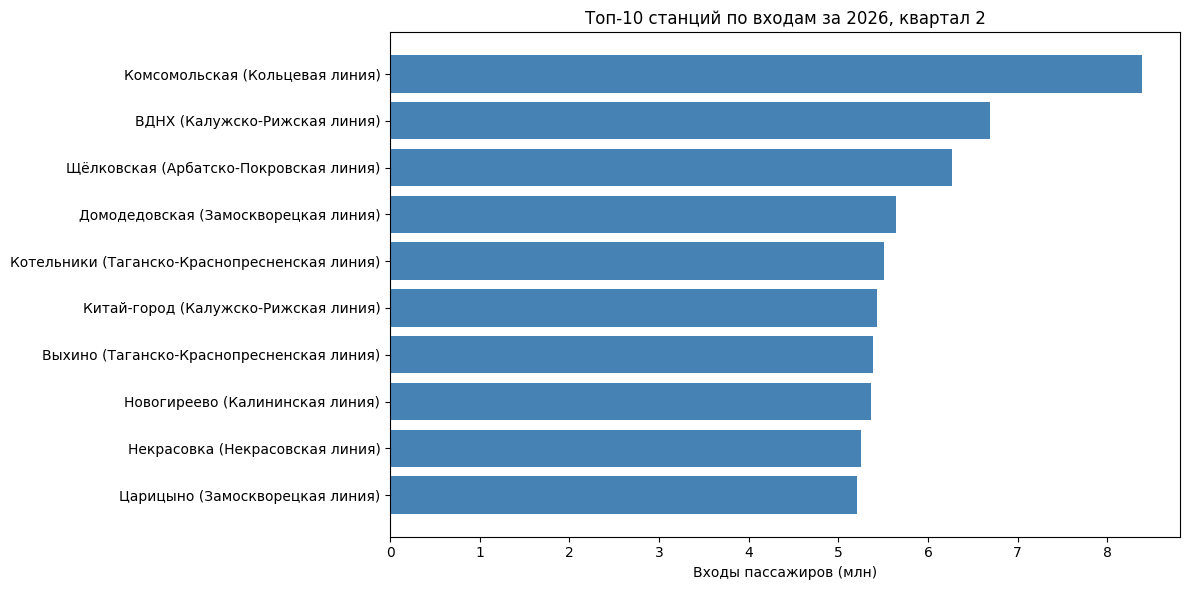

In [100]:
# Подготовьте подписи и значения из top в порядке для графика.
labels = (top['Станция метрополитена'] + ' (' + top['Линия'] + ')').iloc[::-1]
entries_mln = (top['Входы пассажиров'] / 1e6).iloc[::-1]

fig, ax = plt.subplots(figsize=(12, 6))
# Постройте горизонтальные столбцы.
ax.barh(labels, entries_mln, color='steelblue')

# Укажите period_title, подпишите ось, начните её с нуля.
ax.set_title(f'Топ-{TOP_N} станций по входам за {period_title}')
ax.set_xlabel('Входы пассажиров (млн)')
ax.set_xlim(left=0)

plt.tight_layout()
# Сохраните рисунок в OUTPUT_DIR / '01_top_entries.png'.
fig.savefig(OUTPUT_DIR / '01_top_entries.png')
plt.show()

### 2.6. Распределение входов

Постройте гистограмму числа входов на запись за выбранный квартал. Сначала используйте 20 интервалов. Отметьте среднее и медиану, добавьте подписи осей и легенду.

Попробуйте 10 интервалов и сравните вид графика. Сохраните выбранный вариант в `student_outputs/02_distribution.png`.

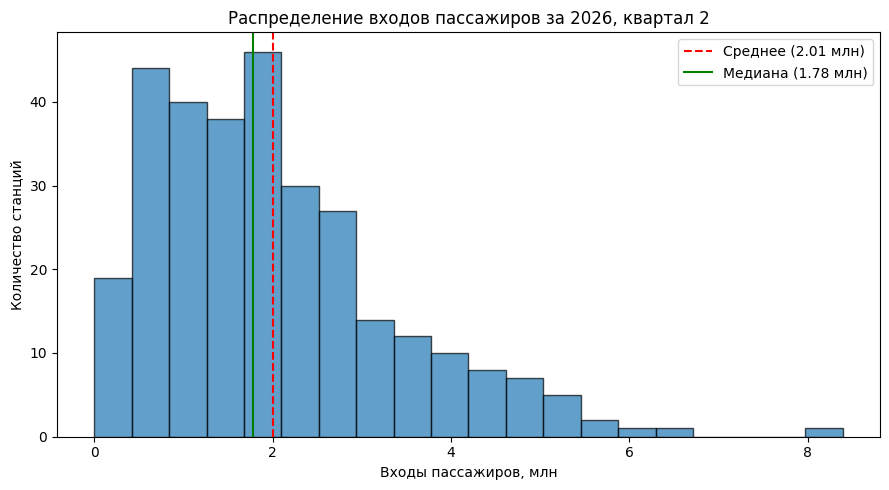

In [ ]:
# Переведите входы из selected в миллионы.
values_mln = selected['Входы пассажиров'] / 1000000
BINS = 20

fig, ax = plt.subplots(figsize=(9, 5))

# Постройте гистограмму, отметьте среднее и медиану.
ax.hist(values_mln, bins=BINS, edgecolor='black', alpha=0.7)

mean_val = values_mln.mean()
median_val = values_mln.median()

ax.axvline(mean_val, color='red', linestyle='--', label=f'Среднее ({mean_val:.2f} млн)')
ax.axvline(median_val, color='green', linestyle='-', label=f'Медиана ({median_val:.2f} млн)')

# Добавьте заголовок с period_title, подписи осей и легенду.
ax.set_title(f'Распределение входов пассажиров за {period_title}')
ax.set_xlabel('Входы пассажиров, млн')
ax.set_ylabel('Количество станций')
ax.legend()

plt.tight_layout()
# Сохраните рисунок в OUTPUT_DIR / '02_distribution.png'.
#fig.savefig(OUTPUT_DIR / '02_distribution.png')

plt.show()

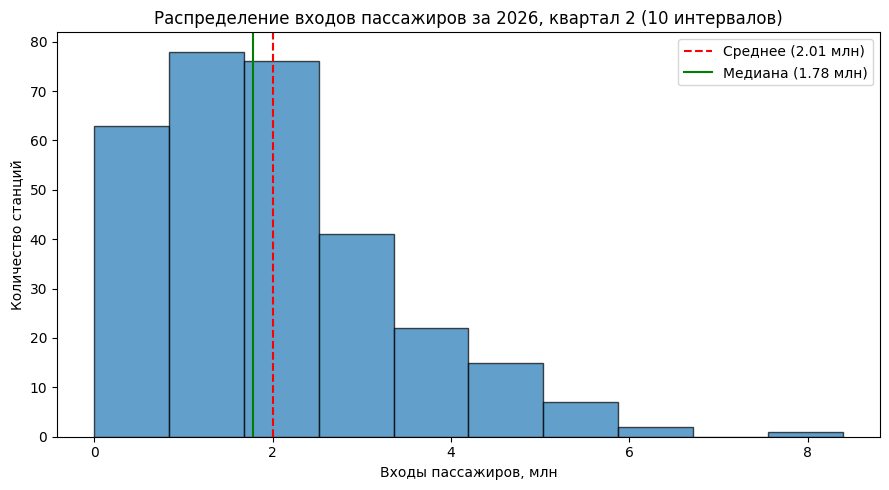

In [ ]:
# Гистограмма с 10 интервалами
BINS = 10

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(values_mln, bins=BINS, edgecolor='black', alpha=0.7)
ax.axvline(mean_val, color='red', linestyle='--',
           label=f'Среднее ({mean_val:.2f} млн)')
ax.axvline(median_val, color='green', linestyle='-',
           label=f'Медиана ({median_val:.2f} млн)')

ax.set_title(f'Распределение входов пассажиров за {period_title} (10 интервалов)')
ax.set_xlabel('Входы пассажиров, млн')
ax.set_ylabel('Количество станций')
ax.legend()

plt.tight_layout()
fig.savefig('02_distribution.png', bbox_inches='tight')
plt.show()

Что видно на гистограмме, чего не видно в рейтинге? Как выбор числа интервалов влияет на восприятие распределения?

В отличие от рейтинга, который показывает только топ-10 самых загруженных станций, гистограмма собирает данные вообще обо всем метро. Видно, что на большинстве станций относительно небольшой поток людей, примерно до 2 млн. человек, а станций с массовым скоплением людей мало. Еще на гистограмме видны нелюдные станции, которые в рейтинг никогда бы не попали.

Выбор числа интервалов зависит от того насколько гистограмма будет детальной. Если взять интервалов слишком мало, то все данные сольются в один два столбца и мы не увидим важные детали. Если сделать много интервалов, то будет трудно увидеть общую форму и закономерности.

### 2.7. Динамика по кварталам — разбор на занятии

Используйте всю подготовленную таблицу. Для каждого квартала посчитайте сумму входов и число записей. Расположите кварталы по времени.

На одном рисунке постройте два графика: сверху — сумму входов, снизу — число записей. Сохраните рисунок в `student_outputs/03_quarterly_coverage.png`.

Это задание выполняется с преподавателем. Если на занятии его пропускаете, остальные задания второй работы должны выполняться независимо от него.

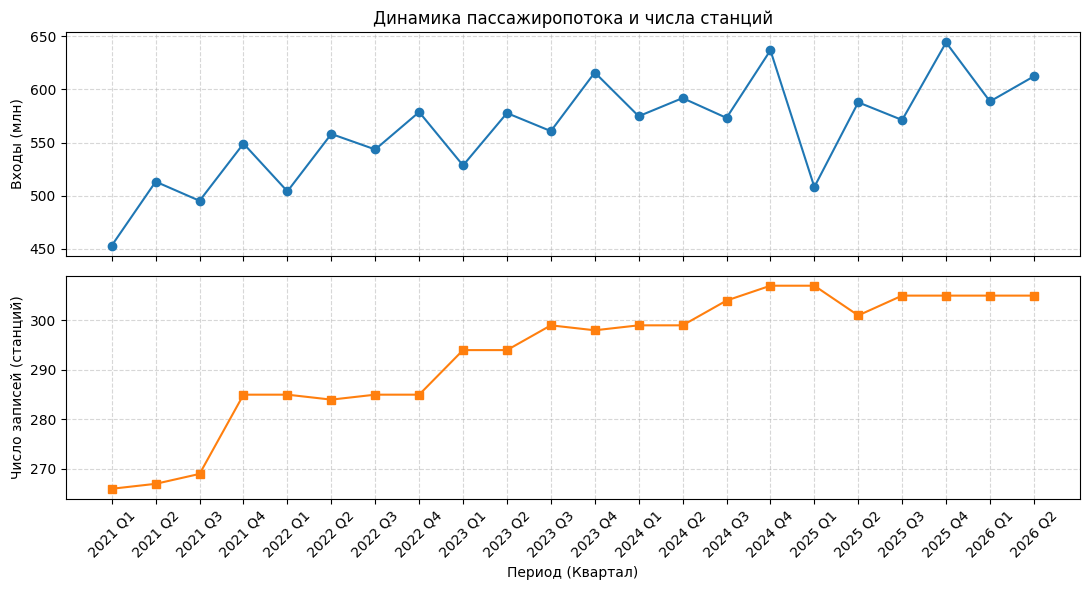

In [ ]:
# По всей df рассчитайте сумму входов и число записей за квартал.
# Названия столбцов сводки: «Входы», «Записей».

# Сначала формируем строку с понятным обозначением периода (например, '2021 Q1')
df_q = df.copy()
df_q['Квартал_текст'] = df_q['Год'].astype(str) + ' Q' + df_q['Номер квартала'].astype(str)

quarterly = df_q.groupby(['Год', 'Номер квартала', 'Квартал_текст']).agg(
    Входы=('Входы пассажиров', 'sum'),
    Записей=('Входы пассажиров', 'count')
).reset_index().sort_values(['Год', 'Номер квартала'])

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

# На axes[0] покажите сумму входов, на axes[1] — число записей.
# Упорядочьте кварталы и подпишите оси.
axes[0].plot(quarterly['Квартал_текст'], quarterly['Входы'] / 1000000, marker='o', color='tab:blue')
axes[0].set_title('Динамика пассажиропотока и числа станций')
axes[0].set_ylabel('Входы (млн)')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(quarterly['Квартал_текст'], quarterly['Записей'], marker='s', color='tab:orange')
axes[1].set_xlabel('Период (Квартал)')
axes[1].set_ylabel('Число записей (станций)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.xticks(rotation=45)
plt.tight_layout()
# Сохраните рисунок в OUTPUT_DIR / '03_quarterly_coverage.png'.
fig.savefig(OUTPUT_DIR / '03_quarterly_coverage.png')
plt.show()

Почему сумму входов за все имеющиеся кварталы одного года не всегда можно напрямую сравнивать с суммой другого года?
Потому что не всегда может быть полное число кварталов за какой-то год и потому что современем открываются новые станции и при этом старые станции могут закрываться. 

### 2.8. Автоматический профиль данных

Создайте HTML-профиль всей подготовленной таблицы с помощью библиотеки профилирования из `requirements.txt`. Используйте семь исходных полей; технические поля периода и номера квартала в профиль не включайте. Год и идентификатор рассматривайте как текстовые поля, входы и выходы — как числовые.

Выберите минимальный режим и сохраните отчёт в `student_outputs/metro_profile.html`. Откройте его в браузере. Сверьте число записей, пропуски и нулевые значения с собственными проверками.

В подготовленной среде используется пакет `fg-data-profiling`, модуль `data_profiling`, класс `ProfileReport`. Порядок работы описан в документации библиотеки; готовый код напишите самостоятельно.

In [103]:
from data_profiling import ProfileReport

PROFILE_MINIMAL = True
profile_path = OUTPUT_DIR / 'metro_profile.html'
profile_data = df[list(column_names.values())].copy()#исходные поля датасета

# Подготовьте типы: год и global_id — текст, счётчики — числа.
if 'Год' in profile_data.columns:
    profile_data['Год'] = profile_data['Год'].astype(str)
if 'global_id' in profile_data.columns:
    profile_data['global_id'] = profile_data['global_id'].astype(str)

profile_data['Входы пассажиров'] = pd.to_numeric(profile_data['Входы пассажиров'], errors='coerce')
profile_data['Выходы пассажиров'] = pd.to_numeric(profile_data['Выходы пассажиров'], errors='coerce')
# Создайте профиль profile_data с выбранным режимом.
profile = ProfileReport(profile_data, minimal=PROFILE_MINIMAL)

# Сохраните профиль в profile_path и откройте его в браузере.
profile.to_file(str(profile_path))

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 569.34it/s]


Выберите два наблюдения из автоматического отчёта. Какие из них требуют проверки, а какие объясняются назначением поля?
1. нулевые значения входов и выходов объясняются назначением поля.
2. global_id имеет большое число уникальных значений, которое объясняется назначением поля и тем что это уникальный идентификатор записи в open data, и он должен быть уникальным для каждого строкового элемента.

### 2.9. Экспорт и повторное чтение

Сохраните рейтинг и сводку по линиям в отдельные CSV. Подготовленную таблицу дополнительно сохраните в JSON, сохранив русские названия и значения.

Заново прочитайте `metro_clean.csv`. Проверьте названия столбцов, число строк и сами значения. При чтении укажите, что `global_id` — строковое поле. Если данные отличаются, найдите причину.

In [ ]:
top_path = OUTPUT_DIR / 'top_entries.csv'
by_line_path = OUTPUT_DIR / 'by_line.csv'
json_path = OUTPUT_DIR / 'metro_clean.json'

# Сохраните top и by_line в CSV, export_df — в JSON.
top.to_csv(top_path, sep=';', index=False, encoding='utf-8-sig')
by_line.to_csv(by_line_path, sep=';', index=False, encoding='utf-8-sig')
export_df.to_json(json_path, orient='records', force_ascii=False, indent=2)

# Заново прочитайте clean_csv_path; global_id должен быть строковым.
reloaded = pd.read_csv(clean_csv_path, sep=';', encoding='utf-8-sig', dtype={'global_id': str})

# Сравните reloaded и export_df: столбцы, число строк и значения.
same_cols = list(reloaded.columns) == list(export_df.columns)
same_rows = len(reloaded) == len(export_df)
same_shape = reloaded.shape == export_df.shape

print(f"Совпадение столбцов: {same_cols}")
print(f"Совпадение количества строк: {same_rows} ({len(reloaded)} строк)")
print(f"Совпадение размерности: {same_shape}")

Совпадение значений: False
Совпадение столбцов: True
Совпадение количества строк: True (6448 строк)
Совпадение размерности: True


### 2.10. Краткая справка

Сформируйте текстовую справку из результатов расчёта и сохраните её в `student_outputs/brief_report.md` или в текстовый файл.

В справке укажите источник и период, число записей в срезе, лидера рейтинга и число входов у него, среднее и медиану, число записей с нулевыми входами. Числовые результаты должны подставляться из расчётов, чтобы справка обновлялась при смене квартала.

Добавьте два ограничения анализа своими словами.

In [105]:
brief_path = OUTPUT_DIR / 'brief_report.md'

# Сформируйте текст справки по top, summary и period_title.
# Числа подставляйте из результатов расчёта.

# Извлекаем метрики из ранее рассчитанных переменных
total_records = len(selected)
top_station = top.iloc[0]['Станция метрополитена']
top_line = top.iloc[0]['Линия']
top_entries = top.iloc[0]['Входы пассажиров']
mean_entries = selected['Входы пассажиров'].mean()
median_entries = selected['Входы пассажиров'].median()
zero_entries_count = (selected['Входы пассажиров'] == 0).sum()

brief = f"""# Краткая справка по пассажиропотоку Московского метрополитена

* **Источник данных:** Единый транспортный портал Москвы (Open Data)
* **Анализируемый период:** {period_title}
* **Количество записей в срезе:** {total_records}
* **Лидер рейтинга:** {top_station} ({top_line}) — {top_entries:,.0f} входов
* **Средний пассажиропоток на запись:** {mean_entries:,.2f} входов
* **Медианный пассажиропоток на запись:** {median_entries:,.2f} входов
* **Записей с нулевыми входами:** {zero_entries_count}

## Ограничения анализа:
1. **Неучёт уникальности пассажиров:** показатель «Входы» отражает общее число проходов через турникеты, а не количество уникальных граждан (один человек может проходить турникет несколько раз в день).
2. **Временные закрытия и изменения сети:** закрытия станций на ремонт, открытие новых радиусов или пересадок меняют структуру пассажиропотока между кварталами, из-за чего показатели разных периодов могут быть несопоставимы напрямую.
"""

# Сохраните brief в brief_path с кодировкой UTF-8.
with open(brief_path, 'w', encoding='utf-8') as f:
    f.write(brief)

print("Справка успешно сформирована и сохранена!")    

Справка успешно сформирована и сохранена!


## Дополнительные задания

Выполняйте их после основной части или по указанию преподавателя. Учебную таблицу с искусственными ошибками не используйте в отчёте по реальным данным.

### 3.1. Учебная таблица с ошибками

Скопируйте первые пять записей подготовленной таблицы, оставив станцию, линию и число входов. В этой копии добавьте пробелы по краям одного названия, замените один счётчик текстом «нет данных», очистите одно название станции и продублируйте одну из остальных строк целиком.

Покажите получившуюся таблицу. Исходную и основную рабочую таблицы не меняйте.

In [106]:
practice_columns = ['Станция метрополитена', 'Линия', 'Входы пассажиров']
practice = df[practice_columns].head(5).astype('string').copy()

# Внесите в practice ошибки из условия и добавьте повтор строки.
# Покажите учебную таблицу; df не изменяйте.

# 1. Добавляем пробелы по краям в названии станции
practice.iloc[0, 0] = '  ' + practice.iloc[0, 0] + '  '

# 2. Заменяем один счётчик текстом «нет данных»
practice.iloc[1, 2] = 'нет данных'

# 3. Очищаем одно название станции (делаем пустую строку)
practice.iloc[2, 0] = ''

# 4. Продублируем одну из оставшихся строк целиком (например, 4-ю строку)
duplicate_row = practice.iloc[[3]].copy()
practice = pd.concat([practice, duplicate_row], ignore_index=True)

print("Учебная таблица с ошибками:")
display(practice)

Учебная таблица с ошибками:


,Станция метрополитена,Линия,Входы пассажиров
0,Митино,Арбатско-Покровская линия,1913498
1,Волоколамская,Арбатско-Покровская линия,нет данных
2,,Арбатско-Покровская линия,1938816
3,Крылатское,Арбатско-Покровская линия,1849616
4,Площадь Революции,Арбатско-Покровская линия,2324687
5,Крылатское,Арбатско-Покровская линия,1849616


### 3.2. Поиск внесённых ошибок

Обработайте учебную таблицу: уберите лишние пробелы, обозначьте пустые строки как пропуски, найдите и удалите полный повтор, преобразуйте счётчик в числа.

Покажите результат и количество пропусков по столбцам. Объясните, откуда появились пропуски после преобразования.

In [107]:
practice_clean = practice.copy()

# Уберите пробелы, обработайте пустые строки и полный повтор.
# Преобразуйте счётчик в числа.
# 1. Убираем лишние пробелы по краям во всех строковых столбцах
for col in ['Станция метрополитена', 'Линия', 'Входы пассажиров']:
    practice_clean[col] = practice_clean[col].str.strip()

# 2. Обозначаем пустые строки как пропуски (NaN)
practice_clean = practice_clean.replace('', pd.NA)

# 3. Находим и удаляем полные дубликаты строк
practice_clean = practice_clean.drop_duplicates()

# 4. Преобразуем счётчик в числа (нечисловые значения станут NaN)
practice_clean['Входы пассажиров'] = pd.to_numeric(practice_clean['Входы пассажиров'], errors='coerce')
# Покажите practice_clean и пропуски после обработки.

display(practice_clean)

print("\nКоличество пропусков по столбцам:")
print(practice_clean.isna().sum())

,Станция метрополитена,Линия,Входы пассажиров
0,Митино,Арбатско-Покровская линия,1913498
1,Волоколамская,Арбатско-Покровская линия,<NA>
2,<NA>,Арбатско-Покровская линия,1938816
3,Крылатское,Арбатско-Покровская линия,1849616
4,Площадь Революции,Арбатско-Покровская линия,2324687



Количество пропусков по столбцам:
Станция метрополитена    1
Линия                    0
Входы пассажиров         1
dtype: int64


1. В столбце «Станция метрополитена» пропуск появился, потому что мы заменили '' на NaN.
2. В столбце «Входы пассажиров» пропуск появился из-за вызова функции pd.to_numeric() с переданным параметром errors='coerce'. Данная функция заменяет все что не является числом на NaN.

### 3.3. Два способа обработки пропусков

Подготовьте два варианта учебной таблицы. В первом исключите записи без названия станции или числового счётчика. Во втором сохраните записи, а отсутствующее название замените меткой «Не указано». Числовые пропуски во втором варианте оставьте.

Сравните число строк и сохранённую информацию. Объясните, для каких целей можно использовать каждый вариант и почему заполнение числового пропуска нулём требует отдельного обоснования.

In [108]:
# Вариант без неполных записей.
practice_complete = practice_clean.dropna(subset=['Станция метрополитена', 'Входы пассажиров']).copy()

# Вариант с текстовой меткой вместо отсутствующего названия.
practice_labels = practice_clean.copy()
practice_labels['Станция метрополитена'] = practice_labels['Станция метрополитена'].fillna('Не указано')
# Заполните только пропуски названия станции.

# Покажите оба варианта и сравните количество строк.
print("\nВариант 1")
display(practice_complete)

print("\nВариант 2")
display(practice_labels)


Вариант 1


,Станция метрополитена,Линия,Входы пассажиров
0,Митино,Арбатско-Покровская линия,1913498
3,Крылатское,Арбатско-Покровская линия,1849616
4,Площадь Революции,Арбатско-Покровская линия,2324687



Вариант 2


,Станция метрополитена,Линия,Входы пассажиров
0,Митино,Арбатско-Покровская линия,1913498
1,Волоколамская,Арбатско-Покровская линия,<NA>
2,Не указано,Арбатско-Покровская линия,1938816
3,Крылатское,Арбатско-Покровская линия,1849616
4,Площадь Революции,Арбатско-Покровская линия,2324687


Первый вариант подходит для математического или статистического анализа (например, расчёта сумм и средних значений).
Второй вариант подходит для отчётов и проведения инвентаризации. Он позволяет пометить ошибку в данных, не удаляя саму строку. Так факт наличия записи сохраняется, а спорные моменты остаются на виду для проверки.

### 3.4. Сводная таблица и диаграмма рассеяния

По реальным данным составьте сводную таблицу: строки — линии, столбцы — кварталы, значения — сумма входов. Покажите небольшой фрагмент. Объясните, что означает пустая ячейка, если она встретилась.

Для квартала из задания 2.1 постройте диаграмму рассеяния: по горизонтали — входы, по вертикали — выходы. Подпишите период и единицы. Опишите видимую связь, не делая выводов о её причине.

Год                            2021                                    2022  \
Номер квартала                    1         2         3         4         1   
Линия                                                                         
Арбатско-Покровская линия  47802354  54352647  51117334  58160862  53899845   
Большая кольцевая линия     5591947   7757742   7000940  10570624  15190953   
Бутовская линия             4644890   5185809   5201289  10840276   5364756   
Замоскворецкая линия       53592764  61216331  59199571  64246886  58396102   
Калининская линия          22370393  24401668  23896478  25751247  23499933   

Год                                            ...      2024      2025  \
Номер квартала                    2         3  ...         4         1   
Линия                                          ...                       
Арбатско-Покровская линия  59098343  57049074  ...  61940287  49911550   
Большая кольцевая линия    15764317  17088879  ...  42329324  38605390   
Бутовская линия             5825762   5739421  ...   6348793   5084513   
Замоскворецкая линия       64904309  62618288  ...  67543827  52178424   
Калининская линия          25921108  25177659  ...  25842808  20569638   

Год                                                          2026            
Номер квартала                    2         3         4         1         2  
Линия                                                                        
Арбатско-Покровская линия  56970420  54130289  62141866  56906904  57024754  
Большая кольцевая линия    42660801  42064757  48756115  45108959  47673310  
Бутовская линия             5781900   5690729   6363571   5956375   5973974  
Замоскворецкая линия       62001516  60480676  67745613  61948664  64624653  
Калининская линия          23601324  22563225  25009225  23062565  24074579  

[5 rows x 22 columns]

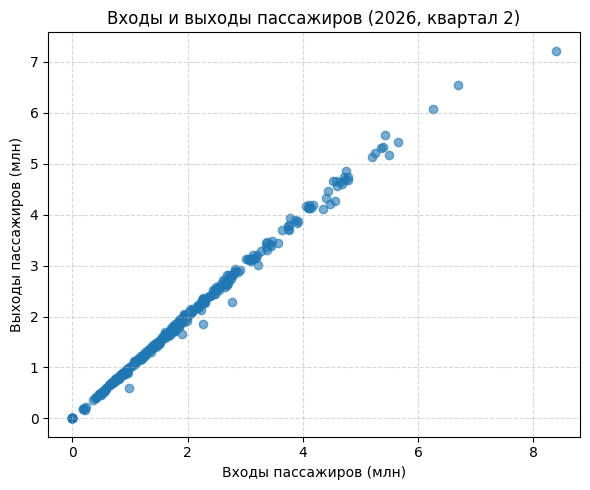

In [109]:
# Сводная таблица по линиям и кварталам из df.
pivot = df.pivot_table(
    index='Линия', 
    columns=['Год', 'Номер квартала'], 
    values='Входы пассажиров', 
    aggfunc='sum'
)

# Покажите небольшой фрагмент pivot.
display(pivot.head(5))

fig, ax = plt.subplots(figsize=(6, 5))
# Постройте диаграмму рассеяния по selected.
# Подпишите входы и выходы в миллионах, укажите period_title.
entries_mln = selected['Входы пассажиров'] / 1000000
exits_mln = selected['Выходы пассажиров'] / 1000000

ax.scatter(entries_mln, exits_mln, alpha=0.6, color='tab:blue')

ax.set_title(f'Входы и выходы пассажиров ({period_title})')
ax.set_xlabel('Входы пассажиров (млн)')
ax.set_ylabel('Выходы пассажиров (млн)')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Пустая ячейка означает, что в данный конкретный период по линии не было ни одной записи в исходном датасете (например, линия ещё не была открыта или по ней не собирались данные).

На диаграмме прослеживается прямая линейная связь между числом входов и выходов. Точки расположены вдоль диагонали: чем выше значение входов на станции, тем больше на ней и значение выходов.

### 3.5. Сравнение одного квартала двух лет

Сравните выбранный квартал с тем же кварталом предыдущего года. Сопоставьте записи по станции и линии. Посчитайте, сколько сочетаний есть в обоих периодах и сколько только в одном.

На общем составе рассчитайте изменение входов в процентах по каждой записи и изменение общей суммы. При нулевой базе процентное изменение оставьте неопределённым. Если общего состава нет, сообщите об этом вместо расчёта.

Поясните, какие различия между периодами могут сохраниться даже после отбора одних и тех же станций и линий.

In [111]:
entity_key = ['Станция метрополитена', 'Линия']
PREVIOUS_YEAR = ANALYSIS_YEAR - 1

# Подготовьте данные одинакового квартала двух лет (используем 'Номер квартала').
prior = df[(df['Год'] == PREVIOUS_YEAR) & (df['Номер квартала'] == ANALYSIS_QUARTER)]
current = df[(df['Год'] == ANALYSIS_YEAR) & (df['Номер квартала'] == ANALYSIS_QUARTER)]

# Агрегируем пассажиропоток по станциям и линиям за каждый период
prior_agg = prior.groupby(entity_key, as_index=False)['Входы пассажиров'].sum().rename(columns={'Входы пассажиров': 'Входы_прошлый'})
current_agg = current.groupby(entity_key, as_index=False)['Входы пассажиров'].sum().rename(columns={'Входы пассажиров': 'Входы_текущий'})

# Сопоставьте записи и проверьте состав объектов.
comparison = pd.merge(prior_agg, current_agg, on=entity_key, how='outer')
matched = comparison.dropna(subset=['Входы_прошлый', 'Входы_текущий']).copy()
only_prior = comparison[comparison['Входы_текущий'].isna()]
only_current = comparison[comparison['Входы_прошлый'].isna()]

print(f"Записей в обоих периодах: {len(matched)}")
print(f"Только в {PREVIOUS_YEAR} году: {len(only_prior)}")
print(f"Только в {ANALYSIS_YEAR} году: {len(only_current)}")

# На общем составе рассчитайте изменение входов по записям
# и общей суммы. Обработайте нулевую базу и пустое пересечение.
if len(matched) == 0:
    print("Общий состав объектов отсутствует, расчет невозможно выполнить.")
else:
    # Процентное изменение по каждой записи (при нулевой базе — NaN)
    matched['Изменение_%'] = matched.apply(
        lambda row: ((row['Входы_текущий'] - row['Входы_прошлый']) / row['Входы_прошлый'] * 100)
        if row['Входы_прошлый'] != 0 else pd.NA,
        axis=1
    )
    
    # Изменение общей суммы
    sum_prior = matched['Входы_прошлый'].sum()
    sum_current = matched['Входы_текущий'].sum()
    
    if sum_prior != 0:
        total_change_pct = (sum_current - sum_prior) / sum_prior * 100
        print(f"Общая сумма входов ({PREVIOUS_YEAR}): {sum_prior:.2f}")
        print(f"Общая сумма входов ({ANALYSIS_YEAR}): {sum_current:.2f}")
        print(f"Изменение общей суммы: {total_change_pct:.2f}%")
    else:
        print("Базовая сумма равна нулю, невозможно рассчитать изменение общей суммы.")

    display(matched)

Записей в обоих периодах: 301
Только в 2025 году: 0
Только в 2026 году: 4
Общая сумма входов (2025): 587893935.00
Общая сумма входов (2026): 610403445.00
Изменение общей суммы: 3.83%


,Станция метрополитена,Линия,Входы_прошлый,Входы_текущий,Изменение_%
0,Авиамоторная,Большая кольцевая линия,1348446,1606303,19.122531
1,Авиамоторная,Калининская линия,2533809,2491816,-1.657307
2,Автозаводская,Замоскворецкая линия,3327525,3356457,0.869475
3,Автозаводская,Московское центральное кольцо,473477,412348,-12.910659
4,Академическая,Калужско-Рижская линия,2854319,2380432,-16.602454
...,...,...,...,...,...
300,Юго-Восточная,Некрасовская линия,1258781,1324504,5.221162
301,Юго-Западная,Сокольническая линия,4515497,4580460,1.438668
302,Южная,Серпуховско-Тимирязевская линия,1931080,1964808,1.746587
303,Ясенево,Калужско-Рижская линия,2637696,2647441,0.369451


Даже после отбора одних и тех же станций и линий между сравниваемыми периодами могут сохраняться существенные различия:

1. Разное количество рабочих и выходных дней в одном и том же квартале разных лет, что влияет на суммарный пассажиропоток.

2. Ремонтные работы, закрытия отдельных вестибюлей или перегонов, изменения в городской инфраструктуре и схемах наземного транспорта.

3. Экономические и социальные факторы — изменения в графиках работы и учебы, распространение удаленного формата работы, колебания туристопотока.

4. Перераспределение потоков — открытие новых близлежащих станций других линий или МЦД, которые могут оттягивать часть пассажиров на себя, даже если состав рассматриваемой линии не менялся.